
# Project Title
Floods prediction using rainfall, river water levels, and soil moisture can help in disaster preparedness and management.

# Problem Statement
Floods prediction as it leads to various loss of life, crops, and infrastructure damage. Predicting flood risk using rainfall, river water levels, soil type can help in disaster preparedness and management.

# Description
The dataset includes environmental, geographical, and socio-economic variables that influence flood occurrence. The goal is to analyze the data and build a predictive model for flood risk management.

In [60]:
# Import Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split


In [61]:
# Load the dataset
flood_data = pd.read_csv(r"C:\Users\juyal\OneDrive\Desktop\skills\flood_risk_dataset_india.csv")

In [62]:
# View first 5 rows to get an idea of the dataset 
print(flood_data.head())

    Latitude  Longitude  Rainfall (mm)  Temperature (°C)  Humidity (%)  \
0  18.861663  78.835584     218.999493         34.144337     43.912963   
1  35.570715  77.654451      55.353599         28.778774     27.585422   
2  29.227824  73.108463     103.991908         43.934956     30.108738   
3  25.361096  85.610733     198.984191         21.569354     34.453690   
4  12.524541  81.822101     144.626803         32.635692     36.292267   

   River Discharge (m³/s)  Water Level (m)  Elevation (m)    Land Cover  \
0             4236.182888         7.415552     377.465433    Water Body   
1             2472.585219         8.811019    7330.608875        Forest   
2              977.328053         4.631799    2205.873488  Agricultural   
3             3683.208933         2.891787    2512.277800        Desert   
4             2093.390678         3.188466    2001.818223  Agricultural   

  Soil Type  Population Density  Infrastructure  Historical Floods  \
0      Clay         7276.742184   

In [63]:
# Dataset information (column names, data types, null counts)
print(flood_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                10000 non-null  float64
 1   Longitude               10000 non-null  float64
 2   Rainfall (mm)           10000 non-null  float64
 3   Temperature (°C)        10000 non-null  float64
 4   Humidity (%)            10000 non-null  float64
 5   River Discharge (m³/s)  10000 non-null  float64
 6   Water Level (m)         10000 non-null  float64
 7   Elevation (m)           10000 non-null  float64
 8   Land Cover              10000 non-null  object 
 9   Soil Type               10000 non-null  object 
 10  Population Density      10000 non-null  float64
 11  Infrastructure          10000 non-null  int64  
 12  Historical Floods       10000 non-null  int64  
 13  Flood Occurred          10000 non-null  int64  
dtypes: float64(9), int64(3), object(2)
memo

In [64]:
# Statistical summary of numerical columns
print(flood_data.describe())

           Latitude     Longitude  Rainfall (mm)  Temperature (°C)  \
count  10000.000000  10000.000000   10000.000000      10000.000000   
mean      22.330627     82.631366     150.015118         29.961401   
std        8.341274      8.389542      86.032127          8.669838   
min        8.000337     68.004575       0.014437         15.000166   
25%       15.143537     75.364428      76.124373         22.405717   
50%       22.283330     82.671007     150.620428         30.000907   
75%       29.460184     89.937897     223.402156         37.413488   
max       36.991813     96.997820     299.970293         44.993681   

       Humidity (%)  River Discharge (m³/s)  Water Level (m)  Elevation (m)  \
count  10000.000000            10000.000000     10000.000000   10000.000000   
mean      59.749104             2515.722946         5.017881    4417.138177   
std       23.142734             1441.706442         2.876579    2530.245421   
min       20.001339                0.042161         0

# check for missing value

In [65]:
# Check for missing values in each column
print(flood_data.isnull().sum())

Latitude                  0
Longitude                 0
Rainfall (mm)             0
Temperature (°C)          0
Humidity (%)              0
River Discharge (m³/s)    0
Water Level (m)           0
Elevation (m)             0
Land Cover                0
Soil Type                 0
Population Density        0
Infrastructure            0
Historical Floods         0
Flood Occurred            0
dtype: int64


# check shape

In [66]:
print("Dataset contains",flood_data.shape[0],"rows and",flood_data.shape[1],"columns[0].")

Dataset contains 10000 rows and 14 columns[0].


# Week 2

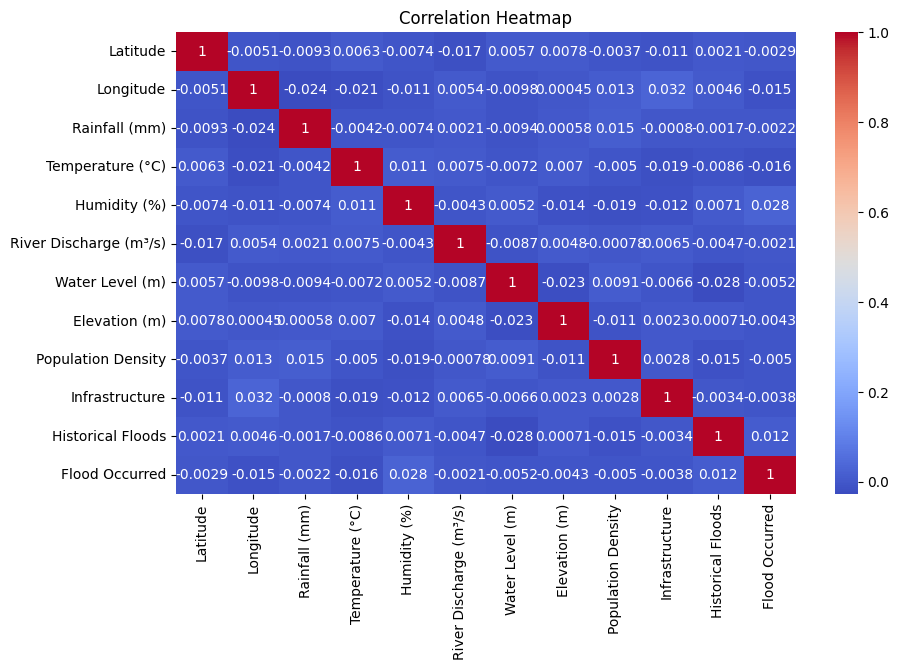

In [67]:
# Exploratory Data Analysis (EDA)

# Correlation heatmap (numerical features only)
plt.figure(figsize=(10,6))
sns.heatmap(flood_data.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


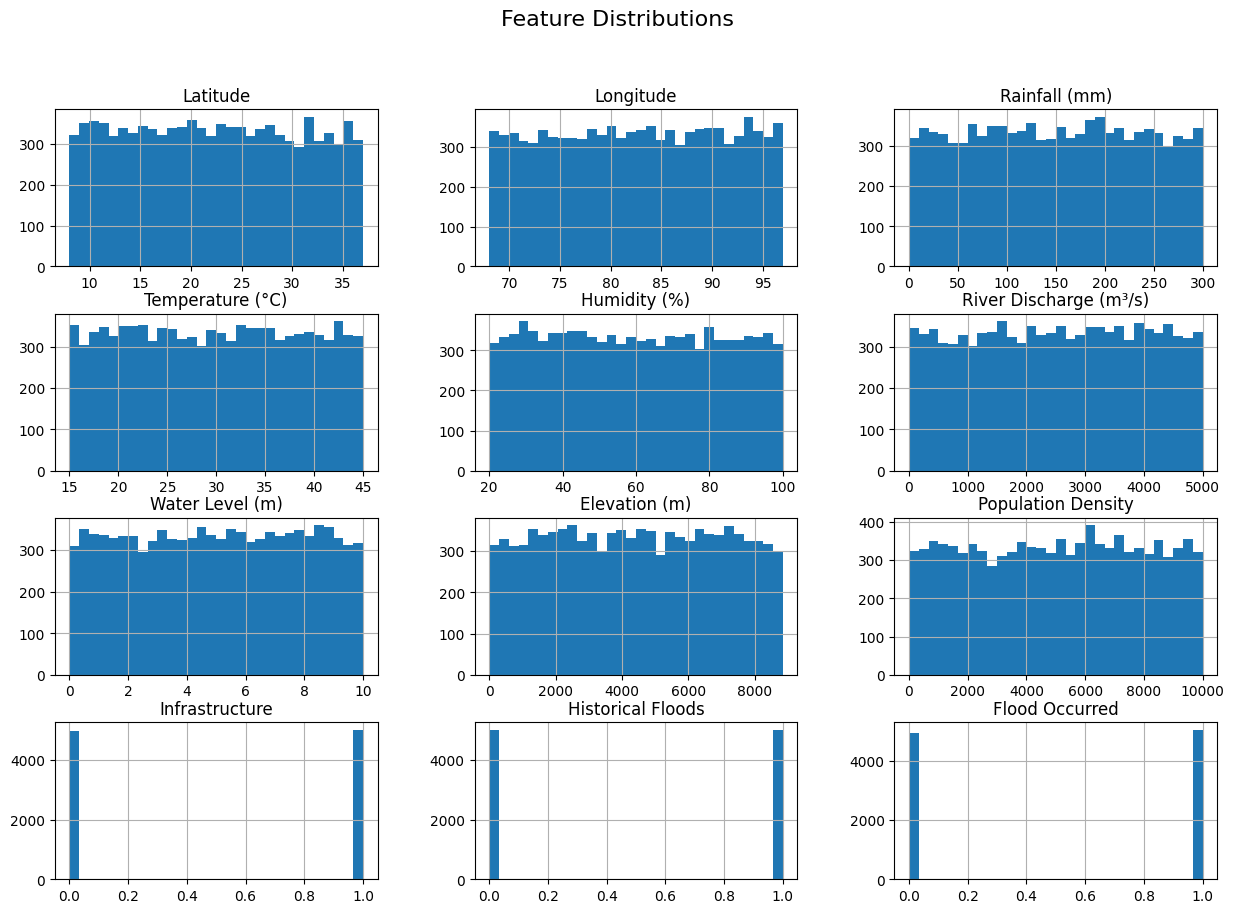

In [68]:
# Distribution plots for numerical features
flood_data.hist(bins=30, figsize=(15,10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


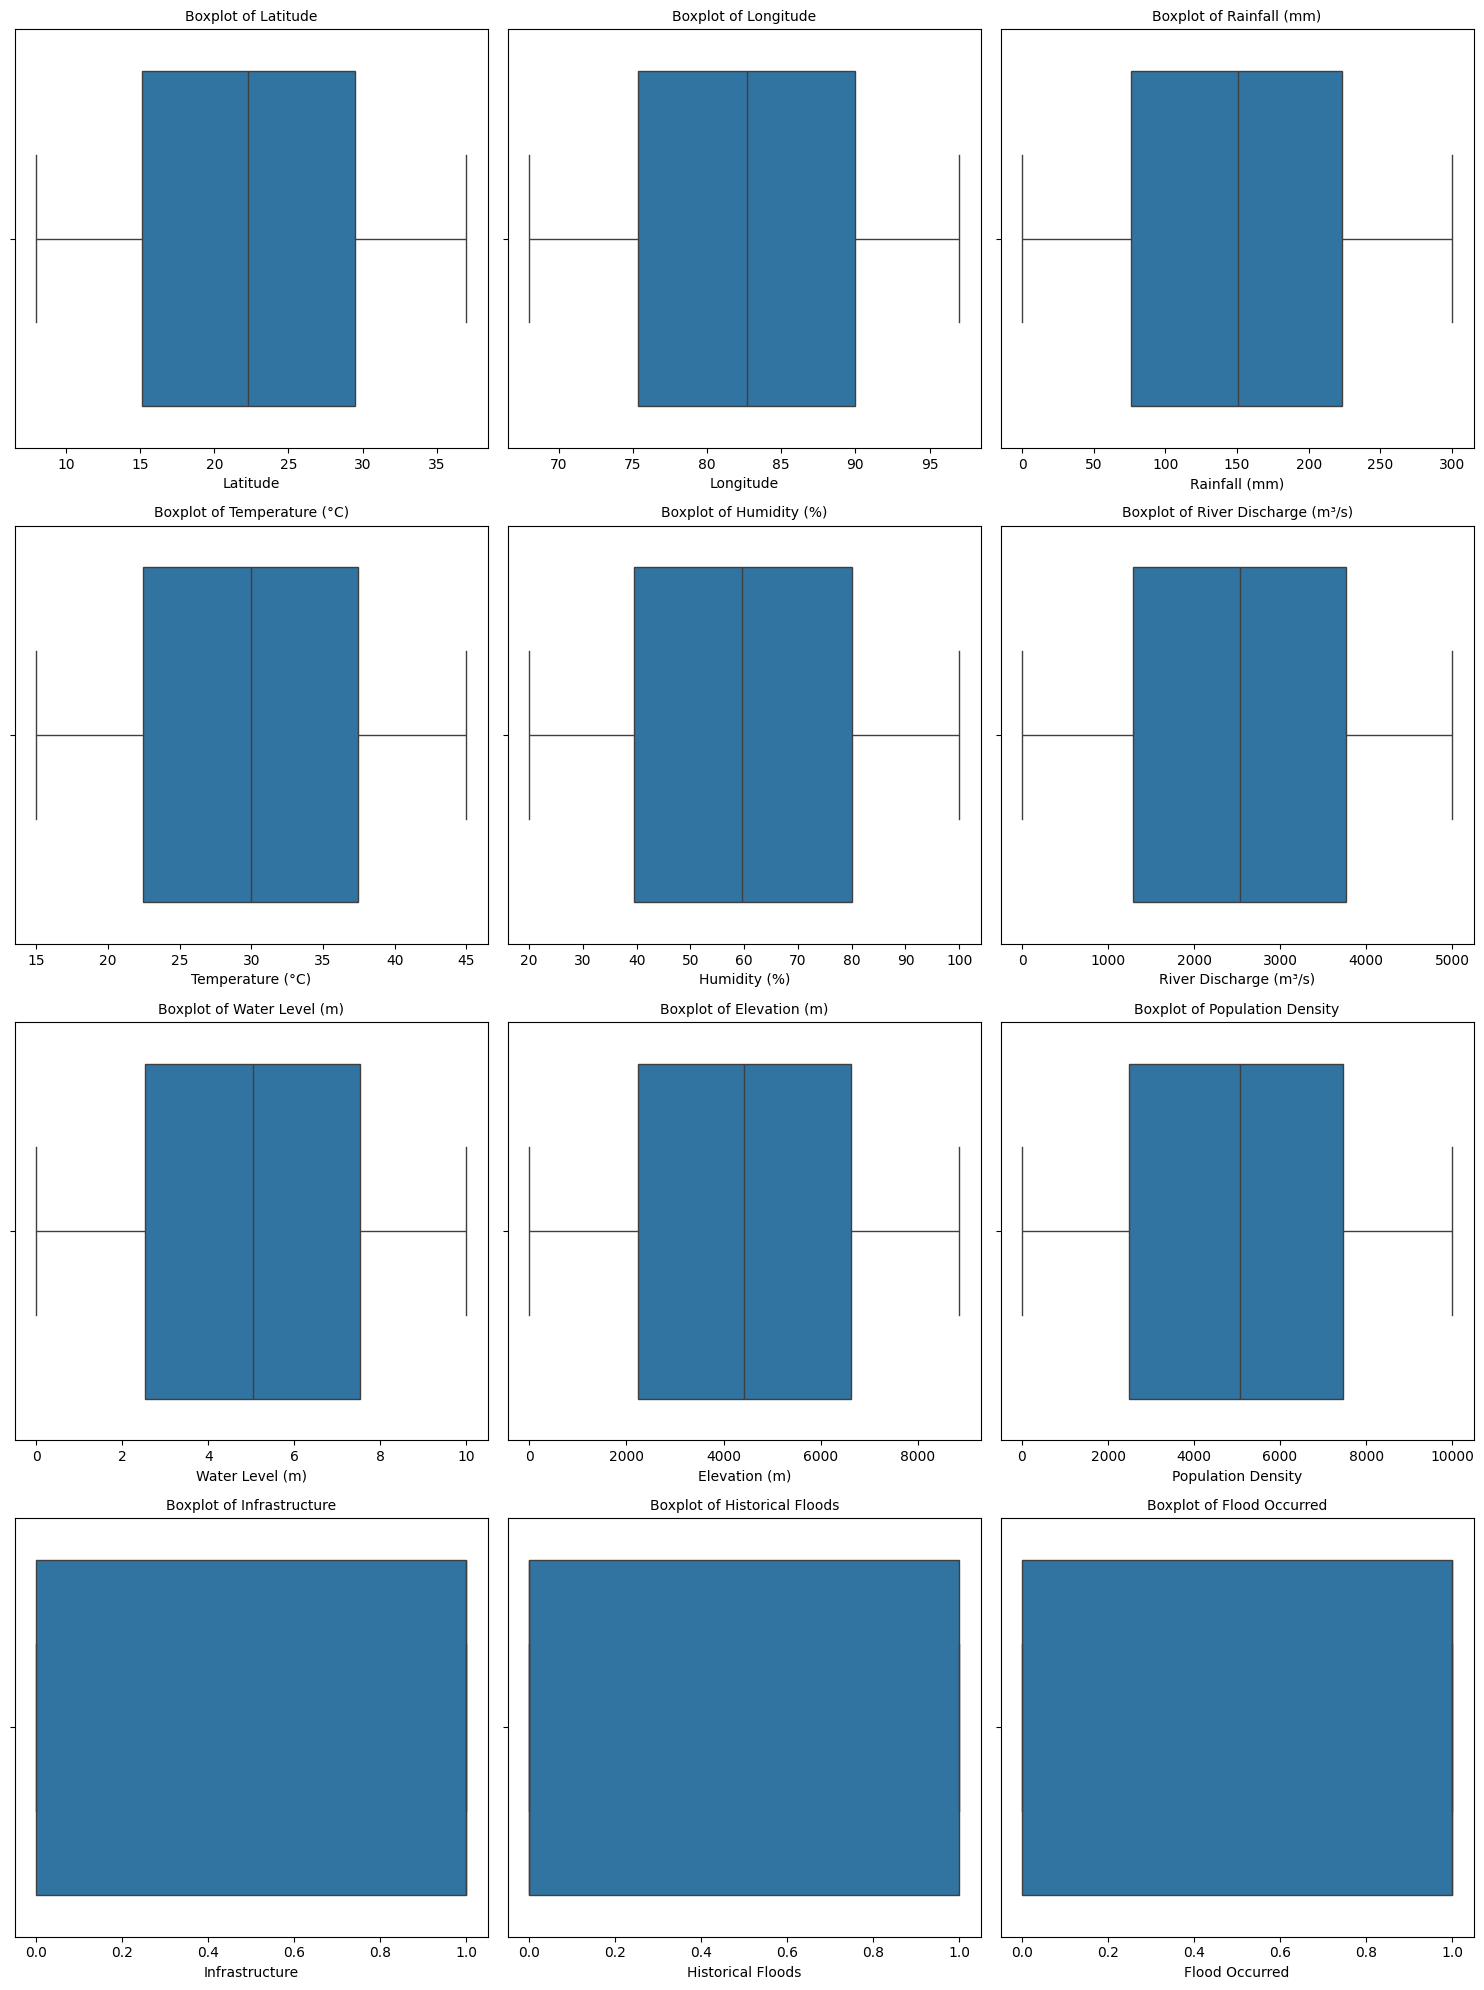

In [69]:
# Boxplots for outlier detection (Subplots)
numeric_cols = flood_data.select_dtypes(include=np.number).columns
num_features = len(numeric_cols)

# Define subplot grid (3 columns per row)
rows = int(np.ceil(num_features / 3))
cols = 3

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=flood_data[col])
    plt.title(f"Boxplot of {col}", fontsize=10)

plt.tight_layout()
plt.show()


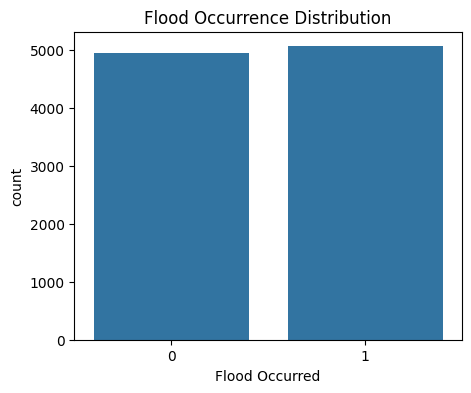

In [70]:
# Target variable distribution
plt.figure(figsize=(5,4))
sns.countplot(x="Flood Occurred", data=flood_data)
plt.title("Flood Occurrence Distribution")
plt.show()


In [71]:
# Data Cleaning & Transformation 

# Handle Missing Values

# Numeric columns -> fill with median
num_cols = flood_data.select_dtypes(include=[np.number]).columns
flood_data[num_cols] = flood_data[num_cols].fillna(flood_data[num_cols].median())

# Categorical columns -> fill with mode
cat_cols = flood_data.select_dtypes(include=['object']).columns
for col in cat_cols:
    flood_data[col] = flood_data[col].fillna(flood_data[col].mode()[0])

print("Missing values handled successfully")


Missing values handled successfully


In [72]:
# Encode categorical variables

le = LabelEncoder()
for col in cat_cols:
    flood_data[col] = le.fit_transform(flood_data[col])

print("Categorical columns encoded")


Categorical columns encoded


In [73]:
# Save Cleaned Dataset

flood_data.to_csv("Flood_Prediction_Cleaned.csv", index=False)
print("Cleaned dataset saved as Flood_Prediction_Cleaned.csv")



Cleaned dataset saved as Flood_Prediction_Cleaned.csv


In [74]:
# Train-Test Split
 
# Reload cleaned data
flood_data_cleaned = pd.read_csv("Flood_Prediction_Cleaned.csv")

In [75]:
# Define target (y) and features (X)
y = flood_data_cleaned["Flood Occurred"]
X = flood_data_cleaned.drop(columns=["Flood Occurred"])

print("\nShape of Features (X):", X.shape)
print("Shape of Target (y):", y.shape)


Shape of Features (X): (10000, 13)
Shape of Target (y): (10000,)


In [76]:
# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (8000, 13)
Testing set shape: (2000, 13)


In [77]:
# Feature Scaling
 
scaler = StandardScaler()

# Fit on training data, transform both train & test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData Preprocessing Completed!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)



Data Preprocessing Completed!
X_train_scaled shape: (8000, 13)
X_test_scaled shape: (2000, 13)
